<a href="https://colab.research.google.com/github/yasminemasmoudi/NLP/blob/master/Tweet_Emotion_Recognition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

I plan to develop a recurrent neural network that can be trained on a tweet emotion dataset, with the aim of enabling the network to accurately identify emotions expressed in tweets. 

The dataset includes thousands of tweets, each of which has been classified into one of six emotions: anger, fear, joy, love, sadness and surprise.

This is a multi-class classification problem that falls within the realm of natural language processing.

To carry out this task, I intend to utilize TensorFlow as our machine learning framework.


Dataset: [Emotions dataset for NLP](https://www.kaggle.com/datasets/praveengovi/emotions-dataset-for-nlp)

Throughout this notebook, I will cover the following topics:


*   Data exploration
*   Data Tokenization
*   Data Padding and Truncating
*   Model creation and Training
*   Model evaluation 

## Importing libraries

In [1]:
%matplotlib inline

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import random

## Importing and Undestanding the Data


In [2]:
train = pd.read_csv("/content/train.txt",sep=";",names=["text","label"])
test = pd.read_csv("/content/test.txt",sep=";",names=["text","label"])
val = pd.read_csv("/content/val.txt",sep=";",names=["text","label"])

In [3]:
train.head()

,text,label
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger


In [4]:
def get_tweet(data):
    tweets = data["text"]
    labels = data["label"]
    return tweets, labels

In [5]:
tweets, labels = get_tweet(train)
print(tweets[0]," : ", labels[0])
print(tweets[20]," : ", labels[20])

i didnt feel humiliated  :  sadness
i feel irritated and rejected without anyone doing anything or saying anything  :  anger


In [6]:
def data_description(data):
    shape = data.shape
    text_nulls = data["text"].isnull().sum()
    label_nulls = data["label"].isnull().sum()
    print("data shape : ",shape)
    print("null values in text field : ", text_nulls)
    print("null values in text field : ", label_nulls)

    data["label"].value_counts()

    plt.hist(data["label"])
    plt.xlabel('emotions')
    plt.ylabel('Frequency')
    plt.title('data distribution')
    plt.show()

Training data description
data shape :  (16000, 2)
null values in text field :  0
null values in text field :  0


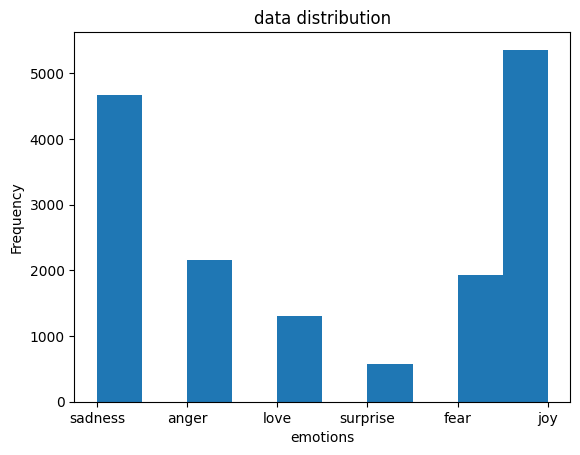

In [7]:
print("Training data description")
data_description(train)

Test data description
data shape :  (2000, 2)
null values in text field :  0
null values in text field :  0


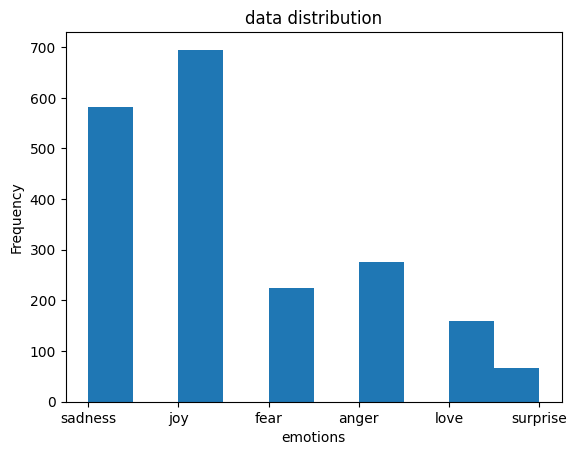

In [8]:
print("Test data description")
data_description(test)

Validation data description
data shape :  (2000, 2)
null values in text field :  0
null values in text field :  0


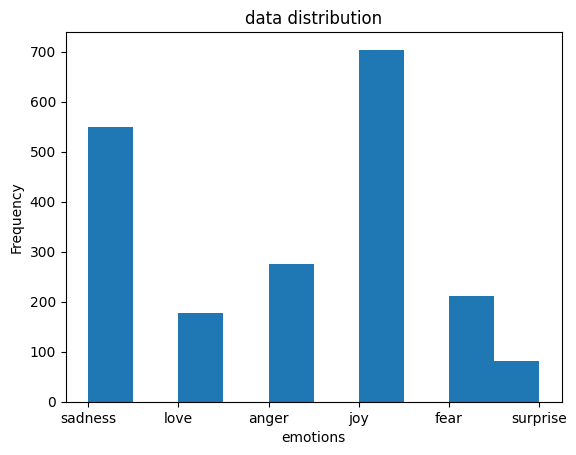

In [9]:
print("Validation data description")
data_description(val)

## Tokenization

In [10]:
from tensorflow.keras.preprocessing.text import Tokenizer

In [11]:
tokenizer = Tokenizer(num_words=10000, oov_token="<UNK>")
tokenizer.fit_on_texts(tweets)

In [12]:
print(tweets[0])
tokenizer.texts_to_sequences([tweets[0]])

i didnt feel humiliated


[[2, 139, 3, 679]]

## Padding and Truncating

In natural language processing (NLP), it is common to use sequences of words as input for models such as neural networks. However, these sequences often have different lengths, which can cause problems when training and using the model.

By padding or truncating the data to a fixed length, we ensure that all sequences have the same length and the model can process them efficiently and effectively. This is particularly important for models such as recurrent neural networks (RNNs) and convolutional neural networks (CNNs) which have a fixed input shape.


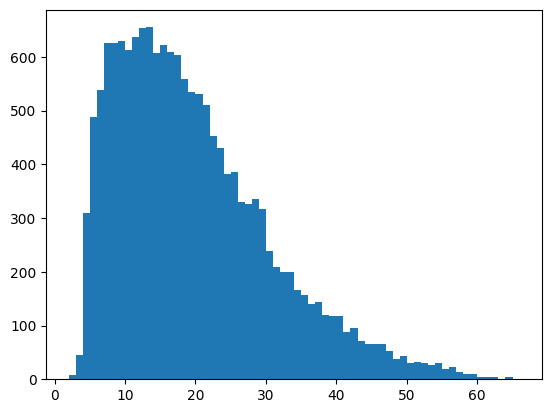

In [13]:
#Checking length of the tweets
lengths = [len(s.split()) for s in tweets]
plt.hist(lengths, bins=len(set(lengths)))
plt.show()

We notice that most of the tweets have less than 50 words

In [14]:
maxlen = 50
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [15]:
#we need to pad or truncate the sequences to a fixed length = variable "maxlen"
def get_sequences(tokenizer, tweets):
    sequences = tokenizer.texts_to_sequences(tweets)
    padded_sequences = pad_sequences(sequences, truncating='post', padding='post', maxlen=maxlen)
    return padded_sequences

In [16]:
padded_train_sequences = get_sequences(tokenizer, tweets)

In [17]:
padded_train_sequences[0]

array([  2, 139,   3, 679,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0], dtype=int32)

## Preparing the Labels

In [18]:
classes = set(labels)
classes

{'anger', 'fear', 'joy', 'love', 'sadness', 'surprise'}

In [21]:
class_to_index = dict((c,i) for i,c in enumerate(classes))
class_to_index

{'love': 0, 'anger': 1, 'sadness': 2, 'joy': 3, 'surprise': 4, 'fear': 5}

In [23]:
index_to_class = dict((value,key) for key , value in class_to_index.items())
index_to_class 

{0: 'love', 1: 'anger', 2: 'sadness', 3: 'joy', 4: 'surprise', 5: 'fear'}

In [24]:
labels_to_ids = lambda labels : np.array([class_to_index.get(x) for x in labels])
ids_to_labels = lambda ids : np.array([index_to_class.get(x) for x in ids])

In [25]:
train_labels = labels_to_ids(labels)
train_labels[0]

2

## Creating the Model

In [26]:
model = tf.keras.Sequential([
    tf.keras.layers.Embedding(10000, 16, input_length=maxlen),
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(20, return_sequences=True)),
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(20)),
    tf.keras.layers.Dense(6, activation='softmax')
])
model.compile(
    loss = 'sparse_categorical_crossentropy',
    optimizer = 'adam',
    metrics = ['accuracy']
)

In [27]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, 50, 16)            160000    
                                                                 
 bidirectional (Bidirectiona  (None, 50, 40)           5920      
 l)                                                              
                                                                 
 bidirectional_1 (Bidirectio  (None, 40)               9760      
 nal)                                                            
                                                                 
 dense (Dense)               (None, 6)                 246       
                                                                 
Total params: 175,926
Trainable params: 175,926
Non-trainable params: 0
_________________________________________________________________


## Training the Model


In [28]:
#Preparing a validation set
val_tweets, val_labels = get_tweet(val)
val_sequences = get_sequences(tokenizer, val_tweets)
val_labels = labels_to_ids(val_labels)

In [30]:
val_tweets[0], val_labels[0]

('im feeling quite sad and sorry for myself but ill snap out of it soon', 2)

In [31]:
#Training the model
m = model.fit(
    padded_train_sequences,
    train_labels,
    validation_data=(val_sequences, val_labels),
    epochs=20,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience = 2)
    ]
)

Epoch 1/20
500/500 [==============================] - 46s 69ms/step - loss: 1.3081 - accuracy: 0.4703 - val_loss: 0.9291 - val_accuracy: 0.6200
Epoch 2/20
500/500 [==============================] - 8s 16ms/step - loss: 0.7066 - accuracy: 0.7200 - val_loss: 0.6567 - val_accuracy: 0.7645
Epoch 3/20
500/500 [==============================] - 8s 17ms/step - loss: 0.4364 - accuracy: 0.8459 - val_loss: 0.5392 - val_accuracy: 0.8290
Epoch 4/20
500/500 [==============================] - 10s 21ms/step - loss: 0.2906 - accuracy: 0.9047 - val_loss: 0.4573 - val_accuracy: 0.8490
Epoch 5/20
500/500 [==============================] - 6s 12ms/step - loss: 0.1921 - accuracy: 0.9386 - val_loss: 0.4649 - val_accuracy: 0.8620
Epoch 6/20
500/500 [==============================] - 7s 14ms/step - loss: 0.1461 - accuracy: 0.9546 - val_loss: 0.4290 - val_accuracy: 0.8665
Epoch 7/20
500/500 [==============================] - 10s 20ms/step - loss: 0.1122 - accuracy: 0.9641 - val_loss: 0.4850 - val_accuracy: 0.8

## Evaluating the Model

In [32]:
def show_history(h):
    epochs_trained = len(h.history['loss'])
    plt.figure(figsize=(16, 6))

    plt.subplot(1, 2, 1)
    plt.plot(range(0, epochs_trained), h.history.get('accuracy'), label='Training')
    plt.plot(range(0, epochs_trained), h.history.get('val_accuracy'), label='Validation')
    plt.ylim([0., 1.])
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(range(0, epochs_trained), h.history.get('loss'), label='Training')
    plt.plot(range(0, epochs_trained), h.history.get('val_loss'), label='Validation')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

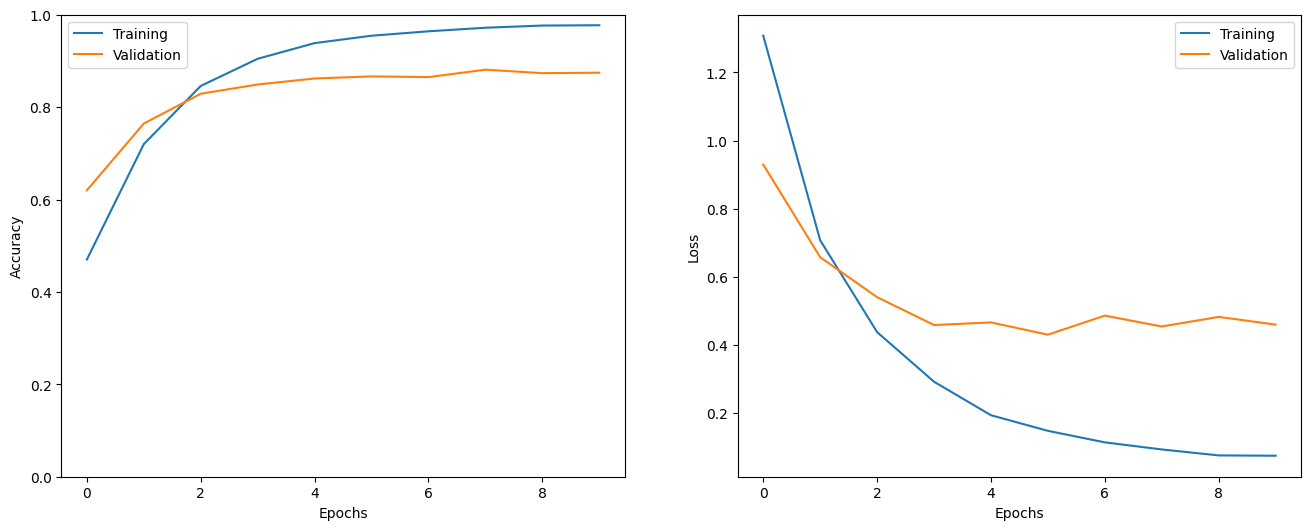

In [33]:
show_history(m)

In [34]:
#Prepraring a test set
test_tweets, test_labels = get_tweet(test)
test_sequences = get_sequences(tokenizer, test_tweets)
test_labels = labels_to_ids(test_labels)

In [35]:
_ = model.evaluate(test_sequences, test_labels)

63/63 [==============================] - 0s 7ms/step - loss: 0.4894 - accuracy: 0.8695


In [36]:
for _ in range(5):
    i = random.randint(0, len(test_labels)-1)
    print("Tweet : ", test_tweets[i]," ==> label : ",index_to_class[test_labels[i]])
    p = model.predict(np.expand_dims(test_sequences[i], axis=0))[0]
    pred_class = index_to_class[np.argmax(p).astype('uint8')]
    print("predicted label : ", pred_class)
    print("-----------------------")

Tweet :  i see all my friends posting pics and status updates of where they are going or what they are doing and i feel a bit jealous knowing it s not something i can get out and enjoy  ==> label :  anger
1/1 [==============================] - 1s 1s/step
predicted label :  anger
-----------------------
Tweet :  i feel like i should be listening to chinesepod and working on my mandarin but what i really want to listen to is the savage love podcast or car talk  ==> label :  anger
1/1 [==============================] - 0s 20ms/step
predicted label :  anger
-----------------------
Tweet :  i persevered through the storm of rejections feeling confident that i was doing what god had called me to do  ==> label :  joy
1/1 [==============================] - 0s 21ms/step
predicted label :  joy
-----------------------
Tweet :  i feel ugly i cover myself with a beautiful blanket in a make believe gown  ==> label :  sadness
1/1 [==============================] - 0s 20ms/step
predicted label :  sadn

In [37]:
def show_confusion_matrix(y_true, y_pred, classes):
    from sklearn.metrics import confusion_matrix
    
    cm = confusion_matrix(y_true, y_pred, normalize='true')

    plt.figure(figsize=(8, 8))
    sp = plt.subplot(1, 1, 1)
    ctx = sp.matshow(cm)
    plt.xticks(list(range(0, 6)), labels=classes)
    plt.yticks(list(range(0, 6)), labels=classes)
    plt.colorbar(ctx)
    plt.show()

In [41]:
predict_x=model.predict(test_sequences) 
classes_x=np.argmax(predict_x,axis=1)

63/63 [==============================] - 0s 6ms/step


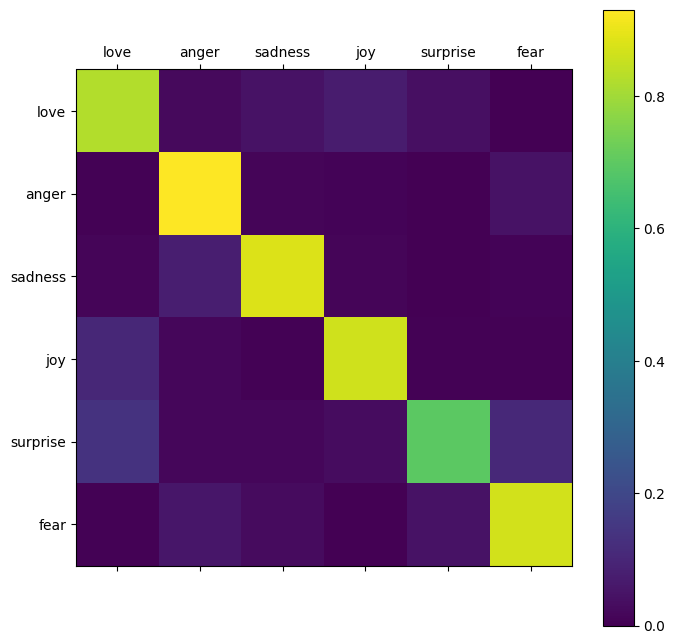

In [42]:
show_confusion_matrix(test_labels, classes_x, list(classes))

The most common misclassifications seem to be between joy-love and fear-surprise.

Its possible that this is due to class inbalance. Class imbalance occurs when the number of samples in one or more classes (surprise, love, fear and anger) of a dataset is significantly lower than the number of samples in other classes (sadness and joy). 

In order to mitigate the effects of class imbalance, there are several techniques that can be applied, such as oversampling the minority class, undersampling the majority class, and adjusting the class weights during training.